# Project - Airline AI Assistant

We'll now bring together what we've learned to make an AI Customer Support assistant for an Airline

In [ ]:
# imports

import os
import json
from dotenv import load_dotenv
from openai import OpenAI
import gradio as gr
import sqlite3

In [ ]:
# Initialization

load_dotenv(override=True)

openai_api_key = os.getenv('GROQ_API_KEY')
if openai_api_key:
    print(f"OpenAI API Key exists and begins {openai_api_key[:8]}")
else:
    print("OpenAI API Key not set")
    
MODEL = "openai/gpt-oss-120b"
openai = OpenAI(base_url="https://api.groq.com/openai/v1", api_key=openai_api_key)

DB = "prices.db"

In [ ]:
system_message = """
You are a helpful assistant for an Airline called FlightAI.
Give short, courteous answers, no more than 1 sentence.
Always be accurate. If you don't know the answer, say so.
"""

In [ ]:
def get_ticket_price(city):
    print(f"DATABASE TOOL CALLED: Getting price for {city}", flush=True)
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute('SELECT price FROM prices WHERE city = ?', (city.lower(),))
        result = cursor.fetchone()
        return f"Ticket price to {city} is ${result[0]}" if result else "No price data available for this city"

In [ ]:
example_prices = {
    "paris": 450,
    "london": 500,
    "new york": 650,
    "tokyo": 900,
    "sydney": 1100,
}

In [ ]:
def add_cities():
    with sqlite3.connect(DB) as conn:
        conn.execute(f""" 
            CREATE TABLE IF NOT EXISTS prices ( 
                city TEXT PRIMARY KEY, 
                price INTEGER NOT NULL 
            ) 
        """)
        conn.executemany(
            "INSERT OR REPLACE INTO prices (city, price) VALUES (?, ?)",
            example_prices.items()
        )

    print("Example city prices added to the database.")

add_cities()

In [ ]:
get_ticket_price("Paris")

In [ ]:
price_function = {
    "name": "get_ticket_price",
    "description": "Get the price of a return ticket to the destination city.",
    "parameters": {
        "type": "object",
        "properties": {
            "destination_city": {
                "type": "string",
                "description": "The city that the customer wants to travel to",
            },
        },
        "required": ["destination_city"],
        "additionalProperties": False
    }
}
tools = [{"type": "function", "function": price_function}]
tools

In [ ]:

def chat(message, history):
    history = [{"role": h["role"], "content": h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model=MODEL, messages=messages)
    return response.choices[0].message.content

gr.ChatInterface(fn=chat).launch()

In [ ]:
def chat(message, history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses = handle_tool_calls(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    
    return response.choices[0].message.content

In [ ]:
def handle_tool_calls(message):
    responses = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses

In [ ]:
gr.ChatInterface(fn=chat).launch()

## A bit more about what Gradio actually does:

1. Gradio constructs a frontend Svelte app based on our Python description of the UI
2. Gradio starts a server built upon the Starlette web framework listening on a free port that serves this Svelte app
3. Gradio creates backend routes for our callbacks, like chat(), which calls our functions

And of course when Gradio generates the frontend app, it ensures that the the Submit button calls the right backend route.

That's it!

It's simple, and it has a result that feels magical.

# Let's go multi-modal!!

We can use gpt-image-1-mini, the image generation model behind GPT-5, to make us some images

Let's put this in a function called artist.

### Price alert: each time I generate an image it costs about 3 cents - don't go crazy with images!

In [58]:
# Some imports for handling images

import base64
from io import BytesIO
from PIL import Image

In [59]:
img_client = OpenAI(
    base_url="https://gen.pollinations.ai/v1",
    api_key=os.getenv("POLLINATIONS_API_KEY")
)

In [72]:
import io
import requests
# from IPython.display import Image, display
from PIL import Image


def artist(city):
    # 1. Clean and encode the prompt text safely into a URL format
    prompt = f"An image representing a vacation in {city}, showing tourist spots and everything unique about {city}, in a vibrant pop-art style"

    # 2. Build the target keyless URL (specifying the 'flux' model explicitly)
    res = img_client.images.generate(
        model="black-forest-labs/flux.1-schnell",  # High-quality open weights image model
        prompt=prompt,
        size="1024x1024",
        n=1,
        response_format="url"
    )

    print(f"Requesting canvas for {city}...")

    try:
        # 3. Pull image bytes directly into memory via HTTP GET
        image_url = res.data[0].url
        response = requests.get(image_url, timeout=30)

        if response.status_code == 200:
            print(f"Success! Displaying artwork for {city}:")
            # 4. Render directly in your Notebook cell layout
            # display(Image(data=response.content))
            img = Image.open(io.BytesIO(response.content))
            return img
        else:
            print(f"Failed to fetch image. Status code: {response.status_code}")

    except Exception as e:
        print(f"An error occurred while grabbing the image: {e}")

Requesting canvas for New York City...
Success! Displaying artwork for New York City:


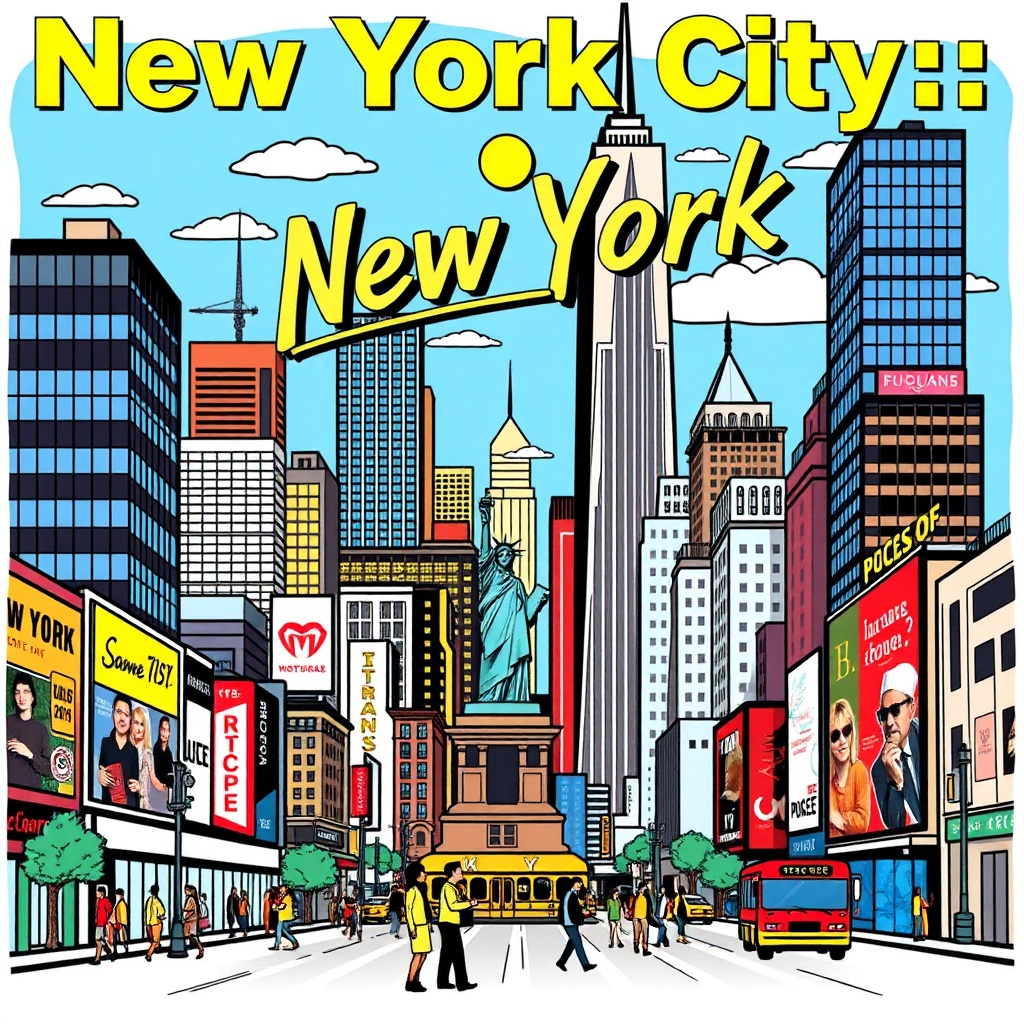

In [73]:
# Test the fixed code
artist("New York City")

In [69]:
def talker(message):
    api_key = os.getenv("OPENROUTER_API_KEY")

    if not api_key:
        raise gr.Error("OPENROUTER_API_KEY is not set.")

    if not message or not message.strip():
        raise gr.Error("Please enter some text.")

    url = "https://openrouter.ai/api/v1/audio/speech"

    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
        "HTTP-Referer": "http://localhost:7860",
        "X-Title": "Gradio TTS App",
    }

    payload = {
        "model": "deepgram/flux-tts:free",
        "voice": "flux-bree-en",
        "input": message.strip(),

        # VERY IMPORTANT:
        # Explicitly request MP3 so the returned bytes are MP3.
        "response_format": "mp3",
    }

    try:
        response = requests.post(
            url,
            headers=headers,
            json=payload,
            timeout=120,
        )

        # Errors from OpenRouter are JSON
        if not response.ok:
            try:
                error = response.json()
            except Exception:
                error = response.text

            raise gr.Error(
                f"OpenRouter error {response.status_code}: {error}"
            )

        # Check what OpenRouter actually returned
        content_type = response.headers.get("content-type", "")

        print("Content-Type:", content_type)
        print("Audio bytes:", len(response.content))
        print(
            "Generation ID:",
            response.headers.get("x-generation-id")
        )

        if not content_type.startswith("audio/"):
            raise gr.Error(
                f"Expected audio response, got: {content_type}"
            )

        if not response.content:
            raise gr.Error("OpenRouter returned empty audio.")

        # Return RAW AUDIO BYTES directly to Gradio
        return response.content

    except requests.RequestException as e:
        raise gr.Error(f"Request failed: {e}")

In [62]:
demo = gr.Interface(
    fn=talker,

    inputs=gr.Textbox(
        label="Text",
        placeholder="Type something...",
        lines=4,
    ),

    outputs=gr.Audio(
        label="Generated Speech",
        type="filepath",
        autoplay=True,
    ),

    title="OpenRouter TTS",
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7870
* To create a public link, set `share=True` in `launch()`.


Content-Type: audio/mpeg
Audio bytes: 4176
Generation ID: gen-tts-1789742172-QEkpzg8o88uMKY8xf5UI


## Let's bring this home:

1. A multi-modal AI assistant with image and audio generation
2. Tool callling with database lookup
3. A step towards an Agentic workflow


In [63]:
def chat(history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history
    response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    cities = []
    image = None

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses, cities = handle_tool_calls_and_return_cities(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    reply = response.choices[0].message.content
    history += [{"role":"assistant", "content":reply}]

    voice = talker(reply)

    if cities:
        image = artist(cities[0])
    
    return history, voice, image


In [64]:
def handle_tool_calls_and_return_cities(message):
    responses = []
    cities = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            cities.append(city)
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses, cities

## The 3 types of Gradio UI

`gr.Interface` is for standard, simple UIs

`gr.ChatInterface` is for standard ChatBot UIs

`gr.Blocks` is for custom UIs where you control the components and the callbacks

In [74]:
# Callbacks (along with the chat() function above)

def put_message_in_chatbot(message, history):
        return "", history + [{"role":"user", "content":message}]

# UI definition

with gr.Blocks() as ui:
    with gr.Row():
        chatbot = gr.Chatbot(height=500)
        image_output = gr.Image(height=500, interactive=False)
    with gr.Row():
        audio_output = gr.Audio(autoplay=True)
    with gr.Row():
        message = gr.Textbox(label="Chat with our AI Assistant:")

# Hooking up events to callbacks

    message.submit(put_message_in_chatbot, inputs=[message, chatbot], outputs=[message, chatbot]).then(
        chat, inputs=chatbot, outputs=[chatbot, audio_output, image_output]
    )

ui.launch(inbrowser=True, auth=("cherry", "pass123"))

* Running on local URL:  http://127.0.0.1:7872
* To create a public link, set `share=True` in `launch()`.


Content-Type: audio/mpeg
Audio bytes: 21456
Generation ID: gen-tts-1789743712-2pY2MdbMIrFW0EHJ03Ir
DATABASE TOOL CALLED: Getting price for Sydney
Content-Type: audio/mpeg
Audio bytes: 25776
Generation ID: gen-tts-1789743739-NUq2VXQZOLaAPgchq3vY
Requesting canvas for Sydney...
Success! Displaying artwork for Sydney:


# Exercises and Business Applications

Add in more tools - perhaps to simulate actually booking a flight. A student has done this and provided their example in the community contributions folder.

Next: take this and apply it to your business. Make a multi-modal AI assistant with tools that could carry out an activity for your work. A customer support assistant? New employee onboarding assistant? So many possibilities! Also, see the week2 end of week Exercise in the separate Notebook.

<table style="margin: 0; text-align: left;">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/thankyou.jpg" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#090;">I have a special request for you</h2>
            <span style="color:#090;">
                My editor tells me that it makes a HUGE difference when students rate this course on Udemy - it's one of the main ways that Udemy decides whether to show it to others. If you're able to take a minute to rate this, I'd be so very grateful! And regardless - always please reach out to me at ed@edwarddonner.com if I can help at any point.
            </span>
        </td>
    </tr>
</table>